# Regime-Based Volatility Forecasting (LSTM)

## Overview
This notebook implements a two-stage forecasting framework for log realized variance. 
The approach combines a regime classification model using LSTM (Stage 1) with a conditional forecasting model using SVR-Linear(Stage 2), evaluated using a rolling window scheme.

## Methodology

The pipeline consists of the following steps:

1. **Feature Engineering**
   - Market, macro, and blockchain features are constructed
   - Lagged volatility features are included

2. **Stage 1: Regime Model**
   - Predicts the probability of being in a high/low volatility regime
   - Model: LSTM

3. **Stage 2: Forecasting Model**
   - The predicted regime probabilities from Stage 1 are used as inputs to the Stage 2 forecasting model.
   - Model: SVR

4. **Evaluation**
   - Rolling/expanding window framework
   - Metrics: RMSE, QLIKE

## Structure of Notebook

- Section 0: Setup and Reproducibility
- Section 1: Data Loading
- Section 2: Feature Construction
- Section 3: LSTM Model
- Section 4: SVR-Linear Model
- Section 5: Evaluation and Results
- Section 6: Post Out-of-Sample Analysis, including classification reports, feature importance, and SHAP values 

### Section 0: Setting Seed for replicability

In [1]:
import os

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)

import random
import numpy as np
import pandas as pd
import tensorflow as tf

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

tf.config.experimental.enable_op_determinism()

## Section 1: Data Loading and Preprocessing

In this section, we load the dataset and construct key features required for modeling.

We first transform realized variance into logarithmic scale to stabilise variance and reduce skewness. We then construct lagged features at lags 1, 2, and 3 to capture temporal dependence in volatility dynamics. Additionally, a 30-day rolling mean of log realized variance is included to capture medium-term trends, as motivated by patterns observed in the ACF and PACF plots. Rows with missing values arising from lagging and rolling operations are removed. All features are constructed using only past information to avoid look-ahead bias.

Finally, the dataset is restricted to observations from July 2017 onwards to ensure consistency in the sample period.

In [2]:
df = pd.read_csv('../data/df_with_2regimes.csv')

# take log of realized variance
df['log_realized_variance'] = np.log(df['realized_variance'])
# lag 1,2 andd 3 of log realized variance
df['rv_lag1'] = df['log_realized_variance'].shift(1)
df['rv_lag2'] = df['log_realized_variance'].shift(2)
df['rv_lag3'] = df['log_realized_variance'].shift(3)

# rolling mean of log realized variance over the past 30 days
df['rv_rolling_mean_30'] = df['log_realized_variance'].rolling(window=30).mean() 

# drop rows with NaN values (due to lag and rolling mean)
df = df.dropna().reset_index(drop=True)
#df.head(30)
#df.info()

# start from 2017-07-13
df = df[df['date'] >= '2017-07-13'].reset_index(drop=True)
#print(df.isna().sum())

## Section 2: Feature construction
The feature sets differ across the two stages to reflect their distinct roles in the modeling framework.

### Stage 1: Regime Model (LSTM)

The LSTM model is provided with a high-dimensional feature set incorporating:
- Volatility and returns
- Blockchain activity indicators
- Cross-asset market returns
- Trading volume and liquidity proxies
- Market uncertainty (VIX)

This rich feature space allows the LSTM to learn complex nonlinear relationships and extract latent regime dynamics from multiple sources of information.

### Stage 2: Forecasting Model (SVR)

In contrast, the SVR model uses a parsimonious set of features:
- Log realized variance
- Lagged volatility (lags 1–3)
- Rolling mean of volatility

This design reflects the role of the second stage, which is to generate forecasts conditional on the regime information produced by Stage 1, rather than re-learning the full feature space.

By restricting the SVR input to core volatility dynamics, we reduce the risk of overfitting and ensure a clearer separation between regime identification and forecasting.

In [2]:
lstm_features = ["log_realized_variance","log_return", "gtrend_pct_change",
    "blockchain_diff_log_n_transactions",
    "blockchain_diff_log_transaction_fee_usd",
    "blockchain_diff_log_n_unique_addresses",
    "blockchain_diff_log_transaction_volume_usd",
    "log_volume",
    "gold_close_ret",
    "silver_close_ret",
    "brent_close_ret",
    "dji_close_ret",
    "spx_close_ret",
    "rut_close_ret",
    "nasdaq_close_ret",
    "usdcny_close_ret",
    "usdeur_close_ret",
    "gold_volume_chg",
    "silver_volume_chg",
    "brent_volume_chg",
    "dji_volume_chg",
    "spx_volume_chg",
    "rut_volume_chg",
    "nasdaq_volume_chg",
    "vix_close_chg",
    "hash-rate_chg",
    "difficulty_chg",
    "median-confirmation-time_chg",
    "blockchain_log_mempool_count_chg"
    ]

svr_features = ["log_realized_variance","rv_lag1", "rv_lag2", "rv_lag3", "rv_rolling_mean_30"]

## Section 3: LSTM Regime Model

In this section, we construct an LSTM-based model to predict volatility regimes. 
The model takes as input a sequence of features up to time \( t \) and outputs the probability of being in each regime at time \( t+1 \), corresponding to a one-step-ahead forecasting setup.

The LSTM architecture is chosen for its ability to capture temporal dependencies and nonlinear dynamics in sequential financial data. To account for class imbalance and the temporal structure of regime switching, we adopt a weighted training objective following Agakishiev et al. (2025). 

The following cells contain a set of key helper functions for weight computation, sequence construction, scaling, and model training and prediction.

### Weighted LSTM Objective

Each observation is assigned a weight

$$
w_t = (1-\lambda)\frac{T}{\sum_{s=1}^{T} \mathbf{1}\{g_t = g_s\}}
+
\lambda
\frac{\sum_{s=1}^{T} \mathbf{1}\{g_s \ne g_{s-1}\}}
{\sum_{s=1}^{T} \mathbf{1}\{g_t = g_s\}\mathbf{1}\{g_s \ne g_{s-1}\}}
$$

where

- $T$ is the number of observations  
- $g_t$ is the regime label at time $t$  
- $\mathbf{1}\{\cdot\}$ is the indicator function  
- $\lambda \in [0,1]$ controls the emphasis on regime switching observations.

The LSTM is trained using a **weighted categorical cross-entropy loss**

$$
\mathcal{L} =
-\frac{1}{T}
\sum_{t=1}^{T}
w_t
\sum_{k=1}^{K}
y_{t,k}\log(\hat{y}_{t,k})
$$

where

- $K$ = number of regimes  
- $y_{t,k}$ = true indicator of regime $k$ at time $t$  
- $\hat{y}_{t,k}$ = predicted probability from the LSTM softmax layer  
- $w_t$ = observation weight.

In [9]:
def compute_weights(regimes, lam=0.5, eps=1e-12):
    regimes = np.asarray(regimes).astype(int)
    T = len(regimes)

    switch_flag = np.zeros(T, dtype=int)
    switch_flag[1:] = (regimes[1:] != regimes[:-1]).astype(int)

    unique_regimes = np.unique(regimes)

    class_count = {g: np.sum(regimes == g) for g in unique_regimes}
    switch_count = {
        g: np.sum((regimes == g) & (switch_flag == 1))
        for g in unique_regimes
    }
    total_switches = np.sum(switch_flag)

    weights = np.zeros(T, dtype=float)

    for t in range(T):
        g = regimes[t]

        imbalance_term = T / (class_count[g] + eps)

        if total_switches > 0 and switch_count[g] > 0:
            switch_term = total_switches / (switch_count[g] + eps)
        else:
            switch_term = 0.0 

        weights[t] = (1 - lam) * imbalance_term + lam * switch_term 

    # normalize weights for stability
    weights = weights / np.mean(weights)

    return weights, switch_flag

In [10]:
# use this for evaluation and testing
def create_rolling_scaled_sequences_range(
    df, feature_cols, target_col, lookback, scale_window, start_idx, end_idx, date_col=None
):
    X, y, dates = [], [], []

    first_valid_idx = max(start_idx, lookback - 1, scale_window - 1)

    for t in range(first_valid_idx, end_idx - 1):

        hist_window = df[feature_cols].iloc[t - scale_window + 1:t + 1]
        seq_window = df[feature_cols].iloc[t - lookback + 1:t + 1]

        target = df[target_col].iloc[t + 1]

        if hist_window.isnull().any().any():
            continue
        if seq_window.isnull().any().any():
            continue
        if pd.isna(target):
            continue

        scaler = StandardScaler()
        scaler.fit(hist_window)

        seq_scaled = scaler.transform(seq_window)

        X.append(seq_scaled)
        y.append(target)

        if date_col is not None:
            dates.append(df[date_col].iloc[t + 1])
        else:
            dates.append(t + 1)

    return np.array(X), np.array(y), dates

In [11]:
def create_rolling_scaled_sequences_range_weights(
    df, feature_cols, target_col, lookback, scale_window,
    start_idx, end_idx, weights_full, date_col=None
):
    X, y, dates, target_idx, w = [], [], [], [], []

    first_valid_idx = max(start_idx, lookback, scale_window)

    for t in range(first_valid_idx, end_idx - 1):
        hist_window = df[feature_cols].iloc[t - scale_window + 1:t + 1]
        seq_window = df[feature_cols].iloc[t - lookback + 1:t + 1]
        target = df[target_col].iloc[t + 1]

        weight = weights_full[t + 1]

        if hist_window.isnull().any().any():
            continue
        if seq_window.isnull().any().any():
            continue
        if pd.isna(target):
            continue
        if pd.isna(weight):
            continue

        scaler = StandardScaler()
        scaler.fit(hist_window)
        seq_scaled = scaler.transform(seq_window)

        X.append(seq_scaled)
        y.append(target)
        w.append(weight)
        target_idx.append(t + 1)

        if date_col is not None:
            dates.append(df[date_col].iloc[t + 1])
        else:
            dates.append(t + 1)

    return np.array(X), np.array(y), dates, np.array(w), np.array(target_idx)


def scale_rolling(df_hist, feature_cols, lookback, scale_window=730):

    scaler_hist = df_hist[feature_cols].iloc[-min(scale_window, len(df_hist)):].copy()

    scaler = StandardScaler()
    scaler.fit(scaler_hist)

    seq_raw = df_hist[feature_cols].iloc[-lookback:].copy()

    seq_scaled = scaler.transform(seq_raw)

    return seq_scaled, scaler


In [12]:
def build_lstm_model(lookback, n_features, n_regimes=2, units=64, dropout=0.2, optimizer="adam"):
    model = Sequential([
        LSTM(units, input_shape=(lookback, n_features)),
        Dropout(dropout),
        Dense(32, activation="relu"),
        Dense(n_regimes, activation="softmax")
    ])

    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [13]:
def rolling_regime_forecast(
    df_full,
    lstm_model,
    feature_cols,
    lookback,
    start_idx,
    end_idx,
    scale_window=730,
    date_col="date",
    target_col="regime_id"
):

    results = []

    for t in range(start_idx - 1, end_idx - 1):

        df_hist = df_full.iloc[:t+1].copy()

        if len(df_hist) < lookback:
            continue

        try:
            seq_scaled, _ = scale_rolling(
                df_hist,
                feature_cols=feature_cols,
                lookback=lookback,
                scale_window=scale_window
            )
        except Exception:
            continue

        X_input = np.expand_dims(seq_scaled, axis=0)

        pred_probs = lstm_model.predict(X_input, verbose=0)
        pred_regime = int(np.argmax(pred_probs))

        results.append({
            "date": df_full.iloc[t][date_col],
            "pred_regime": pred_regime,
            "pred_prob_0": pred_probs[0,0],
            "pred_prob_1": pred_probs[0,1]
        })

    return pd.DataFrame(results)

## Section 4: SVR-Linear Model

In this section, we construct the second-stage forecasting model using a linear Support Vector Regression (SVR). The objective is to forecast next-day log realized variance using recent volatility dynamics together with the regime probabilities generated by the LSTM model.
The following cells contain several key helper functions that implement model estimation, one-step-ahead forecasting, and the rolling-window evaluation procedure.

In [14]:
def one_step_svr_forecast(fitted_svr, x_next):
    
    if fitted_svr is None:
        return np.nan

    try:
        x_next = np.asarray(x_next).reshape(1, -1)
        pred = fitted_svr.predict(x_next)[0]
        return float(pred)
    except Exception:
        return np.nan

    
def fit_svr_safe(X_train, y_train, C=1.0, epsilon=1e-4, min_obs=100):
    if len(X_train) < min_obs:
        return None

    try:
        model = LinearSVR(C=C, epsilon=epsilon, dual=True, max_iter=20000, random_state = SEED)
        model.fit(X_train, y_train)
        return model
    except Exception as e:
        print("LinearSVR fit failed:", e)
        return None

In [15]:
def rolling_lstm_svr_linear_eval(
    df_full,
    regime_forecast_df,
    start_idx,
    end_idx,
    x_feature_cols,
    realized_var_col="log_realized_variance",
    date_col="date",
    rolling_window=365,
    C=1.0,
    epsilon=1e-4,
    min_obs=200,
    use_prob_1_only=True
):
    results = []

    df = df_full.copy()
    regime_df = regime_forecast_df.copy()

    merge_cols = [date_col, "pred_regime", "pred_prob_0", "pred_prob_1"]
    df = df.merge(regime_df[merge_cols], on=date_col, how="left")

    # target is next day's realized variance
    df["rv_lead1"] = df[realized_var_col].shift(-1)

    # row t stores regime forecast for t+1 made using info up to t
    df["prob1_for_next_day"] = df["pred_prob_1"]
    df["prob0_for_next_day"] = df["pred_prob_0"]
    df["regime_for_next_day"] = df["pred_regime"]

    prob_cols = ["prob1_for_next_day"] if use_prob_1_only else ["prob0_for_next_day", "prob1_for_next_day"]
    feature_cols = x_feature_cols + prob_cols

    for t in range(start_idx - 1, end_idx - 1):
        current_row = df.iloc[t]
        next_row = df.iloc[t + 1]

        current_date = current_row[date_col]
        next_date = next_row[date_col]

        # training ends at t-1, so row t is excluded
        window_df = df.iloc[max(0, t - rolling_window + 1): t].copy()

        needed_cols = feature_cols + ["rv_lead1"]
        train_df = window_df[needed_cols].dropna()

        if len(train_df) < min_obs:
            results.append({
                "date": next_date,
                "forecast_origin_date": current_date,
                "actual_var": next_row[realized_var_col],
                "pred_regime": current_row.get("regime_for_next_day", np.nan),
                "pred_prob_0": current_row.get("prob0_for_next_day", np.nan),
                "pred_prob_1": current_row.get("prob1_for_next_day", np.nan),
                "var_svr": np.nan
            })
            continue

        # split continuous features and probability features
        X_train_cont = train_df[x_feature_cols].values
        X_train_prob = train_df[prob_cols].values
        y_train = train_df["rv_lead1"].values

        # scale only continuous features
        scaler = StandardScaler()
        X_train_cont_scaled = scaler.fit_transform(X_train_cont)

        # combine scaled continuous features with raw probabilities
        X_train_final = np.hstack([X_train_cont_scaled, X_train_prob])

        model = fit_svr_safe(
            X_train=X_train_final,
            y_train=y_train,
            C=C,
            epsilon=epsilon,
            min_obs=min_obs
        )

        # prepare current row features for forecasting t+1
        x_t_cont = current_row[x_feature_cols]
        x_t_prob = current_row[prob_cols]

        if x_t_cont.isna().any() or x_t_prob.isna().any():
            pred = np.nan
        else:
            x_t_cont_scaled = scaler.transform(x_t_cont.values.reshape(1, -1))
            x_t_prob_arr = x_t_prob.values.reshape(1, -1)
            x_t_final = np.hstack([x_t_cont_scaled, x_t_prob_arr])

            pred = one_step_svr_forecast(model, x_t_final)

        results.append({
            "date": next_date,
            "forecast_origin_date": current_date,
            "actual_log_var": next_row[realized_var_col],
            "pred_regime": current_row.get("regime_for_next_day", np.nan),
            "pred_prob_0": current_row.get("prob0_for_next_day", np.nan),
            "pred_prob_1": current_row.get("prob1_for_next_day", np.nan),
            "log_var_svr": pred
        })

    return pd.DataFrame(results)

## Miscellaneous
In this section, we define helper functions for computing RMSE and QLIKE, which are used to evaluate model performance.

In [16]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() == 0:
        return np.nan
    return np.sqrt(np.mean((y_true[mask] - y_pred[mask]) ** 2))


def qlike(test_actuals, test_preds): 
    test_actuals = np.asarray(test_actuals, dtype=float)
    test_preds = np.asarray(test_preds, dtype=float)

    test_qlike = np.mean(test_actuals / (test_preds + 1e-10) - np.log(test_actuals / (test_preds + 1e-10)) - 1)

    return test_qlike 


## Section 5: Evaluation and Results

With the necessary helper functions defined above, we proceed to tune the models and evaluate their out-of-sample performance on the test set. The evaluation is structured as follows:

1. Data sample splitting into training, validation, and test sets  
2. Hyperparameter tuning of the LSTM regime model, with the best configuration selected based on the lowest QLIKE on the validation set  
3. Hyperparameter tuning of the SVR-Linear model, conditional on the selected LSTM configuration  
4. Final model estimation using both training and validation data, followed by a rolling-window evaluation to generate one-step-ahead forecasts on the out-of-sample test set  

In [17]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras import backend as K
import tensorflow as tf
import gc
from itertools import product 
from sklearn.svm import SVR
from sklearn.svm import LinearSVR
from sklearn.preprocessing import StandardScaler


In [18]:
n = len(df)

train_size = int(n * 0.60)  # 60/25/15 split
eval_size  = int(n * 0.25)

train_start_idx = 0
train_end_idx   = train_size

eval_start_idx = train_end_idx
eval_end_idx   = eval_start_idx + eval_size

test_start_idx = eval_end_idx
test_end_idx   = n

# split eval into A and B
evalA_size = eval_size // 2

evalA_start_idx = eval_start_idx
evalA_end_idx   = evalA_start_idx + evalA_size

evalB_start_idx = evalA_end_idx
evalB_end_idx   = eval_end_idx

train_df = df.iloc[train_start_idx:train_end_idx].copy()
evalA_df = df.iloc[evalA_start_idx:evalA_end_idx].copy()
evalB_df = df.iloc[evalB_start_idx:evalB_end_idx].copy()
test_df  = df.iloc[test_start_idx:test_end_idx].copy()

print(f"Train set:  {len(train_df)} rows")
print(f"Eval A set: {len(evalA_df)} rows")
print(f"Eval B set: {len(evalB_df)} rows")
print(f"Test set:   {len(test_df)} rows")

Train set:  1875 rows
Eval A set: 390 rows
Eval B set: 391 rows
Test set:   469 rows


In [19]:
train_start_idx = 0
train_end_idx = train_size

eval_start_idx = train_size
eval_end_idx = train_size + eval_size

test_start_idx = eval_end_idx
test_end_idx = len(df)

In [20]:
lstm_grid = {
    "lookback": [20, 30, 60],
    "units": [32, 64],
    "dropout": [0.0, 0.1, 0.2],
    "batch_size": [32,64]
}

lstm_param_grid = []
for lb, units, drop, bs in product(
    lstm_grid["lookback"],
    lstm_grid["units"],
    lstm_grid["dropout"],
    lstm_grid["batch_size"]
):
    lstm_param_grid.append({
        "lookback": lb,
        "units": units,
        "dropout": drop,
        "batch_size": bs
    })


svr_grid = {
    "kernel": ["linear"],
    "C": [0.1, 1.0, 10.0],
    "epsilon": [1e-4, 1e-3, 1e-2]
}

svr_param_grid = []
for kernel, C, epsilon in product(
    svr_grid["kernel"],
    svr_grid["C"],
    svr_grid["epsilon"]
):
    svr_param_grid.append({
        "kernel": kernel,
        "C": C,
        "epsilon": epsilon
    })

print(f"Total LSTM configs: {len(lstm_param_grid)}")
print(f"Total SVR configs: {len(svr_param_grid)}")

Total LSTM configs: 36
Total SVR configs: 9


#### Tune LSTM on fixed SVR

In [ ]:
fixed_svr_params = {
    "kernel": "linear",
    "C": 1.0,
    "epsilon": 1e-4
}

stage2_window = 365
min_obs = 200

lstm_results = []

for i, params in enumerate(lstm_param_grid, 1):
    lb = params["lookback"]
    units = params["units"]
    drop = params["dropout"]
    bs = params["batch_size"]

    print(f"\n[{i}/{len(lstm_param_grid)}] Testing LSTM: {params}")

    try:
        K.clear_session()
        tf.keras.backend.clear_session()
        gc.collect()

        # -----------------------------
        # 1) Train LSTM on TRAIN only
        # -----------------------------
        train_weights_full, train_switch_flags = compute_weights(
            train_df["regime_id"].values, lam=0.5
        )

        X_train_lstm, y_train_regime, train_dates, w_train, train_idx = (
            create_rolling_scaled_sequences_range_weights(
                df=train_df,
                feature_cols=lstm_features,
                target_col="regime_id",
                lookback=lb,
                scale_window=365,
                start_idx=0,
                end_idx=len(train_df),
                weights_full=train_weights_full,
                date_col="date"
            )
        )

        w_train = w_train.astype(np.float32)

        # -----------------------------------
        # 2) Validate LSTM on Eval A only
        # -----------------------------------
        X_evalA_lstm, y_evalA_regime, evalA_dates = create_rolling_scaled_sequences_range(
            df=df,
            feature_cols=lstm_features,
            target_col="regime_id",
            lookback=lb,
            scale_window=365,
            start_idx=evalA_start_idx,
            end_idx=evalA_end_idx,
            date_col="date"
        )

        if len(X_train_lstm) == 0 or len(X_evalA_lstm) == 0:
            print("Skipping: no sequences produced.")
            lstm_results.append({
                **params,
                "evalB_rmse": np.nan,
                "evalB_qlike": np.nan,
                "n_evalB_forecasts": 0,
                "error": "no sequences produced"
            })
            continue

        y_train_cat = to_categorical(y_train_regime, num_classes=2)
        y_evalA_cat = to_categorical(y_evalA_regime, num_classes=2)

        model = build_lstm_model(
            lookback=lb,
            n_features=len(lstm_features),
            n_regimes=2,
            units=units,
            dropout=drop,
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)
        )

        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True
        )

        model.fit(
            X_train_lstm,
            y_train_cat,
            sample_weight=w_train,
            validation_data=(X_evalA_lstm, y_evalA_cat),
            epochs=100,
            batch_size=bs,
            callbacks=[early_stop],
            verbose=0
        )

        # ---------------------------------------------------------
        # 3) Generate regime probabilities on Eval A + Eval B
        #    starting early enough for stage-2 rolling history
        # ---------------------------------------------------------
        regime_start_idx = max(0, evalA_start_idx - stage2_window)

        evalAB_regime_roll = rolling_regime_forecast(
            df_full=df,
            lstm_model=model,
            feature_cols=lstm_features,
            lookback=lb,
            start_idx=regime_start_idx,
            end_idx=evalB_end_idx,
            scale_window=365,
            date_col="date",
            target_col="regime_id"
        )

        # ------------------------------------------------
        # 4) Tune/evaluate stage-2 SVR on Eval B only
        # ------------------------------------------------
        evalB_stage2 = rolling_lstm_svr_linear_eval(
            df_full=df,
            regime_forecast_df=evalAB_regime_roll,
            start_idx=evalB_start_idx,
            end_idx=evalB_end_idx,
            x_feature_cols=svr_features,
            realized_var_col="log_realized_variance",
            date_col="date",
            rolling_window=stage2_window,
            C=fixed_svr_params["C"],
            epsilon=fixed_svr_params["epsilon"],
            min_obs=min_obs,
            use_prob_1_only=True
        )

        evalB_rmse = rmse(evalB_stage2["actual_log_var"], evalB_stage2["log_var_svr"])
        # convert to variance scale for qlike
        evalB_qlike = qlike(np.exp(evalB_stage2["actual_log_var"]), np.exp(evalB_stage2["log_var_svr"]))
        n_evalB_forecasts = evalB_stage2["log_var_svr"].notna().sum()

        lstm_results.append({
            **params,
            "evalB_rmse": evalB_rmse,
            "evalB_qlike": evalB_qlike,
            "n_evalB_forecasts": n_evalB_forecasts
        })

    except Exception as e:
        print(f"Error for params {params}: {e}")
        lstm_results.append({
            **params,
            "evalB_rmse": np.nan,
            "evalB_qlike": np.nan,
            "n_evalB_forecasts": 0,
            "error": str(e)
        })

lstm_results_df = pd.DataFrame(lstm_results).sort_values("evalB_qlike")
#print(lstm_results_df.head())


[1/36] Testing LSTM: {'lookback': 20, 'units': 32, 'dropout': 0.0, 'batch_size': 32}


/Users/jasonlow/Desktop/DSE4211-GRP13/tfenv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E0000 00:00:1776953301.185821  224456 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2


[2/36] Testing LSTM: {'lookback': 20, 'units': 32, 'dropout': 0.0, 'batch_size': 64}


/Users/jasonlow/Desktop/DSE4211-GRP13/tfenv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E0000 00:00:1776953366.724924  224456 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2


[3/36] Testing LSTM: {'lookback': 20, 'units': 32, 'dropout': 0.1, 'batch_size': 32}


...


[35/36] Testing LSTM: {'lookback': 60, 'units': 64, 'dropout': 0.2, 'batch_size': 32}


/Users/jasonlow/Desktop/DSE4211-GRP13/tfenv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E0000 00:00:1776955563.800269  224456 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2


[36/36] Testing LSTM: {'lookback': 60, 'units': 64, 'dropout': 0.2, 'batch_size': 64}


/Users/jasonlow/Desktop/DSE4211-GRP13/tfenv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E0000 00:00:1776955632.660066  224456 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2

    lookback  units  dropout  batch_size  evalB_rmse  evalB_qlike  \
24        60     32      0.0          32    0.937955     0.460933   
16        30     32      0.2          32    0.940640     0.467597   
34        60     64      0.2          32    0.940339     0.468649   
25        60     32      0.0          64    0.940800     0.470504   
30        60     64      0.0          32    0.940133     0.470683   

    n_evalB_forecasts  
24                391  
16                391  
34                391  
25                391  
30                391  


## Tune svr on best LSTM parameters

In [ ]:
best_lstm_params = lstm_results_df.iloc[0].to_dict()
#print(best_lstm_params)

{'lookback': 60.0, 'units': 32.0, 'dropout': 0.0, 'batch_size': 32.0, 'evalB_rmse': 0.9379547282455007, 'evalB_qlike': 0.4609329827848337, 'n_evalB_forecasts': 391.0}


In [25]:
K.clear_session()
tf.keras.backend.clear_session()
gc.collect()

best_lb = int(best_lstm_params["lookback"])
best_units = int(best_lstm_params["units"])
best_drop = float(best_lstm_params["dropout"])
best_bs = int(best_lstm_params["batch_size"])

train_weights_full, train_switch_flags = compute_weights(
    train_df["regime_id"].values, lam=0.5
)

# 1) Train LSTM on TRAIN only
X_train_lstm, y_train_regime, train_dates, w_train, train_idx = (
    create_rolling_scaled_sequences_range_weights(
        df=train_df,
        feature_cols=lstm_features,
        target_col="regime_id",
        lookback=best_lb,
        scale_window=365,
        start_idx=0,
        end_idx=len(train_df),
        weights_full=train_weights_full,
        date_col="date"
    )
)

w_train = w_train.astype(np.float32)
y_train_cat = to_categorical(y_train_regime, num_classes=2)

# 2) Validate / early stop on EVAL A only
X_evalA_lstm, y_evalA_regime, evalA_dates = create_rolling_scaled_sequences_range(
    df=df,
    feature_cols=lstm_features,
    target_col="regime_id",
    lookback=best_lb,
    scale_window=365,
    start_idx=evalA_start_idx,
    end_idx=evalA_end_idx,
    date_col="date"
)

y_evalA_cat = to_categorical(y_evalA_regime, num_classes=2)

best_lstm_model = build_lstm_model(
    lookback=best_lb,
    n_features=len(lstm_features),
    n_regimes=2,
    units=best_units,
    dropout=best_drop,
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

best_lstm_model.fit(
    X_train_lstm,
    y_train_cat,
    sample_weight=w_train,
    validation_data=(X_evalA_lstm, y_evalA_cat),
    epochs=100,
    batch_size=best_bs,
    callbacks=[early_stop],
    verbose=0
)

# 3) Generate fixed regime probabilities for SVR tuning on Eval B
# start early enough so stage-2 has rolling history
stage2_window = 365
regime_start_idx = max(0, evalB_start_idx - stage2_window)

eval_regime_fixed = rolling_regime_forecast(
    df_full=df,
    lstm_model=best_lstm_model,
    feature_cols=lstm_features,
    lookback=best_lb,
    start_idx=regime_start_idx,
    end_idx=evalB_end_idx,
    scale_window=365,
    date_col="date",
    target_col="regime_id"
)

/Users/jasonlow/Desktop/DSE4211-GRP13/tfenv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E0000 00:00:1776956773.051061  224456 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2

In [ ]:
svr_results = []

for i, params in enumerate(svr_param_grid, 1):
    kernel = params["kernel"]
    C = params["C"]
    epsilon = params["epsilon"]

    print(f"\n[{i}/{len(svr_param_grid)}] Testing SVR: {params}")

    try:
        evalB_svr = rolling_lstm_svr_linear_eval(
            df_full=df,
            regime_forecast_df=eval_regime_fixed,
            start_idx=evalB_start_idx,
            end_idx=evalB_end_idx,
            x_feature_cols=svr_features,
            realized_var_col="log_realized_variance",
            date_col="date",
            rolling_window=365,
            C=C,
            epsilon=epsilon,
            min_obs=200,
            use_prob_1_only=True
        )

        evalB_rmse = rmse(evalB_svr["actual_log_var"], evalB_svr["log_var_svr"])
        # convert to variance scale for qlike
        evalB_qlike = qlike(np.exp(evalB_svr["actual_log_var"]), np.exp(evalB_svr["log_var_svr"]))
        n_evalB_forecasts = evalB_svr["log_var_svr"].notna().sum()

        svr_results.append({
            **params,
            "evalB_rmse": evalB_rmse,
            "evalB_qlike": evalB_qlike,
            "n_evalB_forecasts": n_evalB_forecasts
        })

    except Exception as e:
        svr_results.append({
            **params,
            "evalB_rmse": np.nan,
            "evalB_qlike": np.nan,
            "n_evalB_forecasts": 0,
            "error": str(e)
        })

svr_results_df = pd.DataFrame(svr_results).sort_values("evalB_qlike")
#print(svr_results_df.head())


[1/9] Testing SVR: {'kernel': 'linear', 'C': 0.1, 'epsilon': 0.0001}

[2/9] Testing SVR: {'kernel': 'linear', 'C': 0.1, 'epsilon': 0.001}

[3/9] Testing SVR: {'kernel': 'linear', 'C': 0.1, 'epsilon': 0.01}

[4/9] Testing SVR: {'kernel': 'linear', 'C': 1.0, 'epsilon': 0.0001}

[5/9] Testing SVR: {'kernel': 'linear', 'C': 1.0, 'epsilon': 0.001}

[6/9] Testing SVR: {'kernel': 'linear', 'C': 1.0, 'epsilon': 0.01}

[7/9] Testing SVR: {'kernel': 'linear', 'C': 10.0, 'epsilon': 0.0001}

[8/9] Testing SVR: {'kernel': 'linear', 'C': 10.0, 'epsilon': 0.001}

[9/9] Testing SVR: {'kernel': 'linear', 'C': 10.0, 'epsilon': 0.01}
   kernel     C  epsilon  evalB_rmse  evalB_qlike  n_evalB_forecasts
5  linear   1.0   0.0100    0.948320     0.482345                391
3  linear   1.0   0.0001    0.948830     0.483699                391
4  linear   1.0   0.0010    0.948943     0.483702                391
6  linear  10.0   0.0001    0.947689     0.493967                391
7  linear  10.0   0.0010    0.9

In [ ]:
best_svr_params = svr_results_df.iloc[0].to_dict()
#print(best_svr_params)

{'kernel': 'linear', 'C': 1.0, 'epsilon': 0.01, 'evalB_rmse': 0.948320032057754, 'evalB_qlike': 0.48234457069095604, 'n_evalB_forecasts': 391}


## out of sample testing

In [31]:
K.clear_session()
tf.keras.backend.clear_session()
gc.collect()

best_lb = int(best_lstm_params["lookback"])
best_units = int(best_lstm_params["units"])
best_drop = float(best_lstm_params["dropout"])
best_bs = int(best_lstm_params["batch_size"])



# =====================================================
# FINAL LSTM TRAINING FOR OUT-OF-SAMPLE TEST
# Train on all data before test = TRAIN + EVAL
# =====================================================
train_eval_df = df.iloc[:test_start_idx].copy()

train_eval_weights_full, train_eval_switch_flags = compute_weights(
    train_eval_df["regime_id"].values, lam=0.5
)

# 1) Train final LSTM on TRAIN + EVAL
X_train_eval_lstm, y_train_eval_regime, train_eval_dates, w_train_eval, train_eval_idx = (
    create_rolling_scaled_sequences_range_weights(
        df=train_eval_df,
        feature_cols=lstm_features,
        target_col="regime_id",
        lookback=best_lb,
        scale_window=365,
        start_idx=0,
        end_idx=len(train_eval_df),
        weights_full=train_eval_weights_full,
        date_col="date"
    )
)

w_train_eval = w_train_eval.astype(np.float32)
y_train_eval_cat = to_categorical(y_train_eval_regime, num_classes=2)

final_lstm_model = build_lstm_model(
    lookback=best_lb,
    n_features=len(lstm_features),
    n_regimes=2,
    units=best_units,
    dropout=best_drop,
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)
)

early_stop_final = EarlyStopping(
    monitor="loss",
    patience=10,
    restore_best_weights=True
)

final_lstm_model.fit(
    X_train_eval_lstm,
    y_train_eval_cat,
    sample_weight=w_train_eval,
    epochs=100,
    batch_size=best_bs,
    callbacks=[early_stop_final],
    verbose=0
)

# 2) Generate regime probabilities for TEST
stage2_window = 365
test_regime_start_idx = max(0, test_start_idx - stage2_window)

test_regime_roll = rolling_regime_forecast(
    df_full=df,
    lstm_model=final_lstm_model,
    feature_cols=lstm_features,
    lookback=best_lb,
    start_idx=test_regime_start_idx,
    end_idx=test_end_idx,
    scale_window=365,
    date_col="date",
    target_col="regime_id"
)

/Users/jasonlow/Desktop/DSE4211-GRP13/tfenv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E0000 00:00:1776957003.336947  224456 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2

In [ ]:
### TO SAVE THE FINAL MODEL (UNCOMMENT BELOW) ###

#import os

#os.makedirs("model_final", exist_ok=True)
#final_lstm_model.save("model_final/lstm_model_final3.keras")

In [36]:
best_svr_C = best_svr_params["C"]
best_svr_param_e = best_svr_params["epsilon"]

test_svr = rolling_lstm_svr_linear_eval(
    df_full=df,
    regime_forecast_df=test_regime_roll,
    start_idx=test_start_idx,
    end_idx=test_end_idx,
    x_feature_cols=svr_features,
    realized_var_col="log_realized_variance",
    date_col="date",
    rolling_window=365,
    C=float(best_svr_C),
    epsilon=float(best_svr_param_e),
    min_obs=200,
    use_prob_1_only=True
)

if len(test_svr) == 0:
    raise ValueError("No stage-2 SVR forecasts produced on test set.")

# RMSE on log-variance scale
test_rmse = rmse(
    test_svr["actual_log_var"],
    test_svr["log_var_svr"]
)

# RMSE on variance scale
test_rmse_var = rmse(
    np.exp(test_svr["actual_log_var"]),
    np.exp(test_svr["log_var_svr"])
)

# QLIKE on variance scale
test_qlike = qlike(
    np.exp(test_svr["actual_log_var"]),
    np.exp(test_svr["log_var_svr"])
)

print("Final Test RMSE :", test_rmse)
print("Final Test RMSE (var scale):", test_rmse_var)
print("Final Test QLIKE:", test_qlike)
print("Number of test forecasts:", test_svr["log_var_svr"].notna().sum())

Final Test RMSE : 0.9796247657814311
Final Test RMSE (var scale): 0.0006662977250219346
Final Test QLIKE: 0.5250502891219616
Number of test forecasts: 469


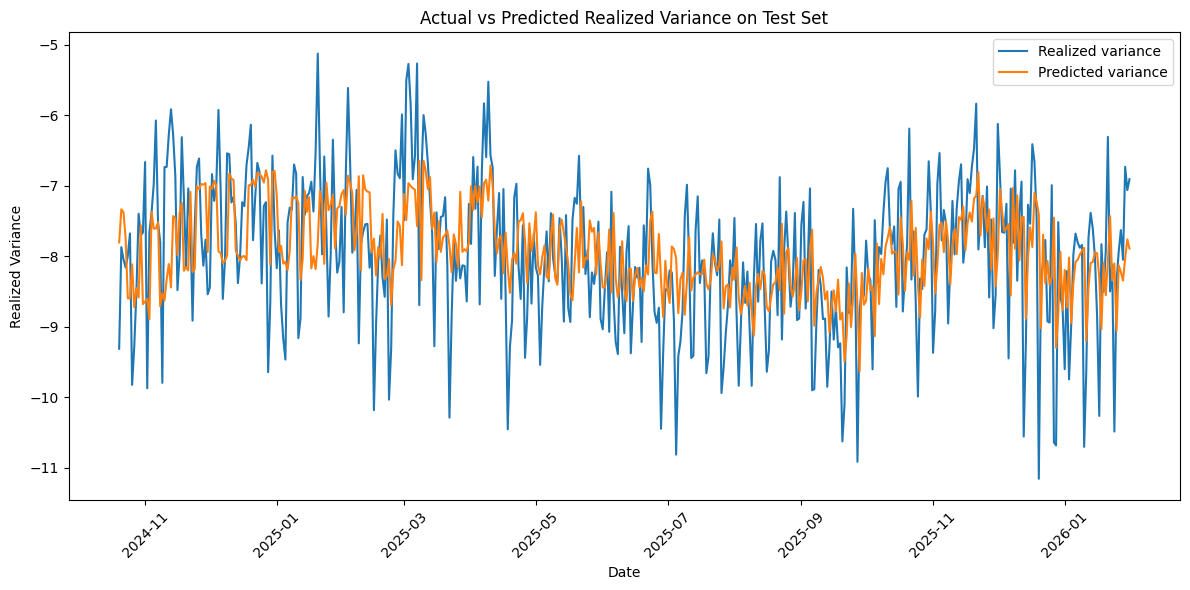

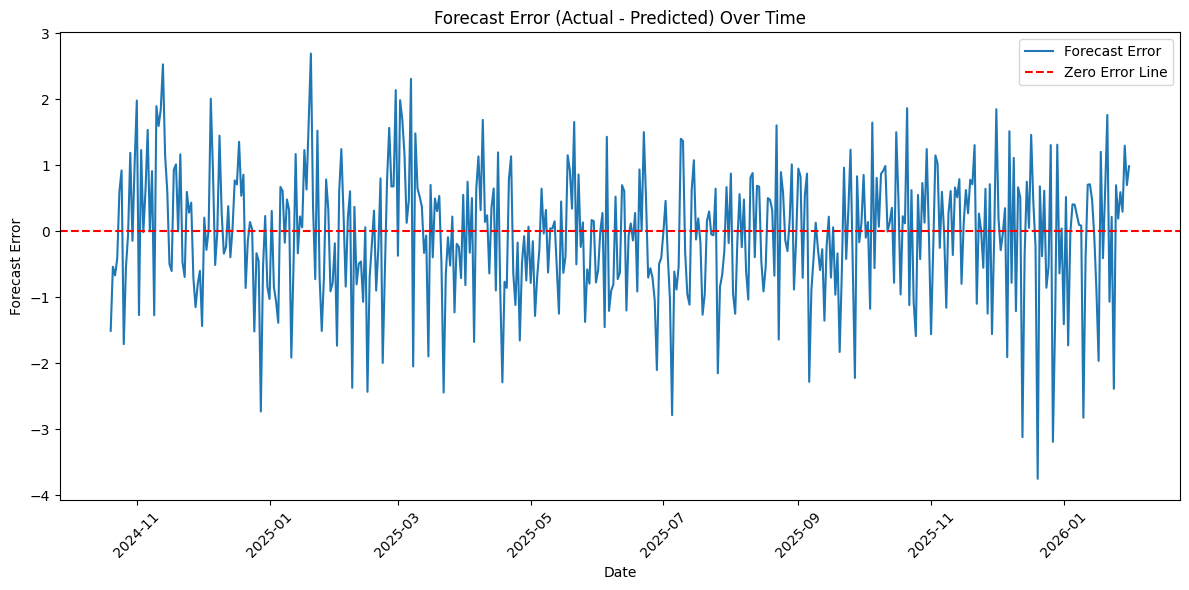

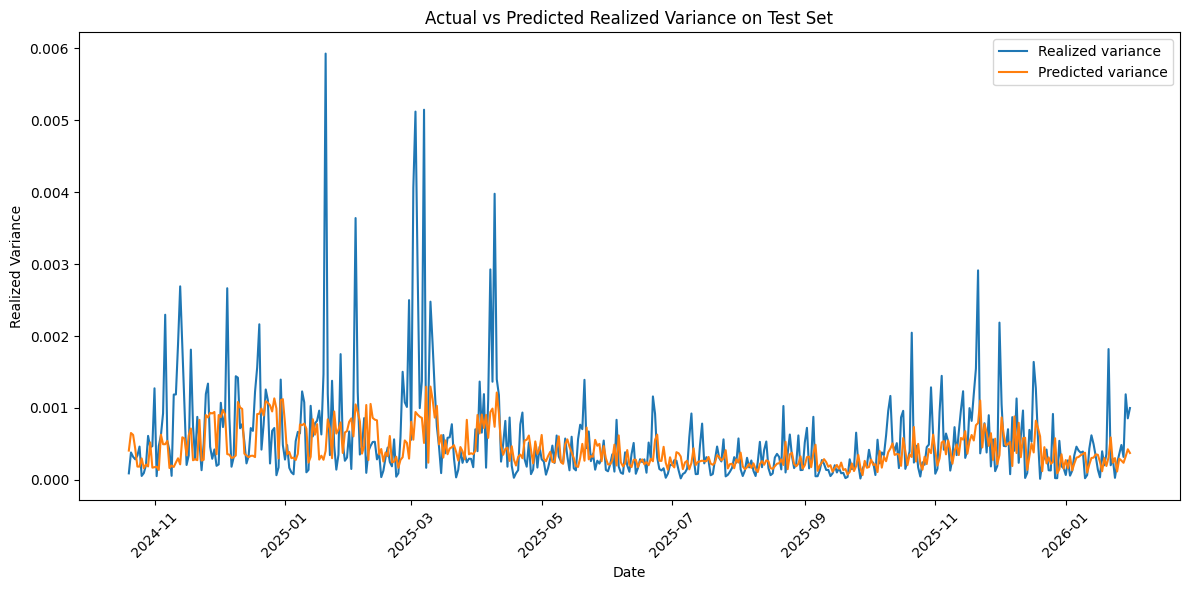

In [38]:
# plot actual vs predicted variance on test set
import matplotlib.pyplot as plt
test_svr['date'] = pd.to_datetime(test_svr['date'])
plt.figure(figsize=(12,6))
plt.plot(test_svr["date"], test_svr["actual_log_var"], label="Realized variance")
plt.plot(test_svr["date"], test_svr["log_var_svr"], label="Predicted variance")
plt.title("Actual vs Predicted Realized Variance on Test Set")
plt.xlabel("Date")
plt.ylabel("Realized Variance")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# plot errors over time
test_svr['date'] = pd.to_datetime(test_svr['date'])
test_svr['error'] = test_svr["actual_log_var"] - test_svr["log_var_svr"]
plt.figure(figsize=(12,6))
plt.plot(test_svr["date"], test_svr["error"], label="Forecast Error") 
plt.axhline(0, color='red', linestyle='--', label="Zero Error Line")
plt.title("Forecast Error (Actual - Predicted) Over Time")
plt.xlabel("Date")
plt.ylabel("Forecast Error")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


test_svr['date'] = pd.to_datetime(test_svr['date'])
plt.figure(figsize=(12,6))
plt.plot(test_svr["date"], np.exp(test_svr["actual_log_var"]), label="Realized variance")
plt.plot(test_svr["date"], np.exp(test_svr["log_var_svr"]), label="Predicted variance")
plt.title("Actual vs Predicted Realized Variance on Test Set")
plt.xlabel("Date")
plt.ylabel("Realized Variance")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# To save the test set predictions and actuals to CSV (uncomment below)
#test_svr.to_csv("results/lstm-svr3.csv", index=False)

## Section 6: Post Out-of-Sample Analysis

In this section, we evaluate the performance of both the LSTM regime model (Stage 1) and the Linear SVR forecasting model (Stage 2) using out-of-sample test data.

For the regime model, performance is assessed using classification metrics such as accuracy and the classification report. For the forecasting model, we examine predictive accuracy using RMSE and QLIKE.

Additionally, we analyse feature importance and apply SHAP values to interpret the contribution of individual features to the model’s predictions.

In [ ]:
# Analyze regime classification performance on test set by merging predicted regimes with actual regimes from df

df['date'] = pd.to_datetime(df['date'])
test_svr['date'] = pd.to_datetime(test_svr['date'])

result_df = test_svr.merge(
    df[["date", "regime_id"]],
    on="date",
    how="left"
)

result_df = result_df.rename(columns={"regime_id": "actual_regime"}) 

#result_df.head(20)

## Classification Report

In [ ]:
# classification report of predicted regime vs actual regime on test set
from sklearn.metrics import classification_report
# drop rows with NaN in pred_regime or actual_regime
result_df_clf = result_df.dropna(subset=["pred_regime", "actual_regime"])
print(classification_report(result_df_clf["actual_regime"], result_df_clf["pred_regime"]))


              precision    recall  f1-score   support

         0.0       0.56      0.64      0.60       214
         1.0       0.66      0.58      0.62       255

    accuracy                           0.61       469
   macro avg       0.61      0.61      0.61       469
weighted avg       0.61      0.61      0.61       469



## Feature importance

In [42]:
from sklearn.metrics import f1_score


def macro_f1_metric(y_true, y_pred):
    y_pred = np.array(y_pred)

    # multiclass / softmax case
    if y_pred.ndim == 2 and y_pred.shape[1] > 1:
        y_pred_class = np.argmax(y_pred, axis=1)
    # binary sigmoid case
    else:
        y_pred_class = (y_pred.ravel() >= 0.5).astype(int)

    return f1_score(y_true, y_pred_class, average="macro")

In [43]:
def permutation_importance_lstm(model, X, y, metric_fn):
    baseline_pred = model.predict(X, verbose=0)
    baseline_score = metric_fn(y, baseline_pred)

    importances = []

    for j in range(X.shape[2]):  # loop over features
        X_permuted = X.copy()

        # permute feature j across samples
        perm_idx = np.random.permutation(X.shape[0])
        X_permuted[:, :, j] = X_permuted[perm_idx, :, j]

        perm_pred = model.predict(X_permuted, verbose=0)
        perm_score = metric_fn(y, perm_pred)

        importance = baseline_score - perm_score
        importances.append(importance)

    return np.array(importances)

In [44]:
X_test_lstm, y_test_regime, test_dates = create_rolling_scaled_sequences_range(
    df=test_df,
    feature_cols=lstm_features,
    target_col="regime_id",
    lookback=best_lb,
    scale_window=365,
    start_idx=0,
    end_idx=len(test_df),
    date_col="date"
)

importances = permutation_importance_lstm(
    model=final_lstm_model,
    X=X_test_lstm,
    y=y_test_regime,
    metric_fn=macro_f1_metric
)

E0000 00:00:1776957345.014088  224456 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [45]:
importance_df = pd.DataFrame({
    "feature": lstm_features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(importance_df)

                                       feature  importance
20                              dji_volume_chg    0.066143
1                                   log_return    0.052764
28            blockchain_log_mempool_count_chg    0.047890
7                                   log_volume    0.038820
9                             silver_close_ret    0.038820
6   blockchain_diff_log_transaction_volume_usd    0.036746
8                               gold_close_ret    0.028514
11                               dji_close_ret    0.026754
2                            gtrend_pct_change    0.026255
21                              spx_volume_chg    0.022393
23                           nasdaq_volume_chg    0.018305
19                            brent_volume_chg    0.017451
22                              rut_volume_chg    0.013485
12                               spx_close_ret    0.011781
26                              difficulty_chg    0.010334
5       blockchain_diff_log_n_unique_addresses    0.0091

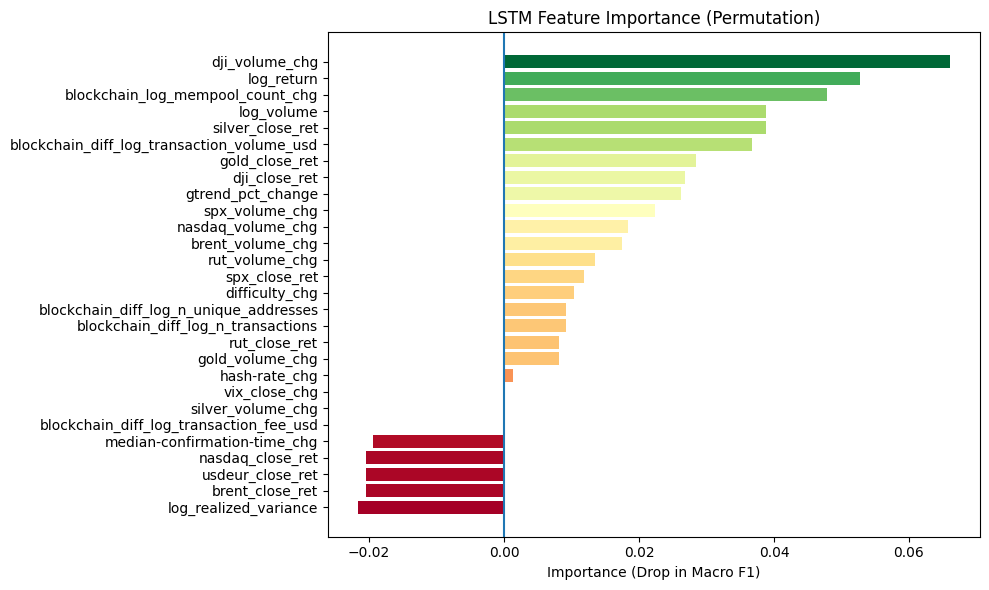

In [46]:
import matplotlib.pyplot as plt
import numpy as np

top_n = 28
plot_df = importance_df.head(top_n).iloc[::-1]

values = plot_df["importance"].values

# normalize values to [-1, 1]
norm = plt.Normalize(vmin=values.min(), vmax=values.max())


cmap = plt.cm.RdYlGn

colors = cmap(norm(values))

plt.figure(figsize=(10, 6))
plt.barh(plot_df["feature"], plot_df["importance"], color=colors)

plt.axvline(0)

plt.title("LSTM Feature Importance (Permutation)")
plt.xlabel("Importance (Drop in Macro F1)")

plt.tight_layout()
plt.show()

## Shapely values

E0000 00:00:1776961488.904802  224456 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


X_test_lstm shape: (104, 60, 29)
X_test_flat shape: (104, 1740)
background shape: (30, 1740)
X_explain shape: (100, 1740)


100%|██████████| 100/100 [27:33<00:00, 16.54s/it]
/var/folders/2h/gvrjdw1x6t766jgk66w62_tw0000gn/T/ipykernel_7229/799558395.py:112: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


SHAP computed.
3D SHAP output detected: (100, 1740, 2)
Selected SHAP array shape: (100, 1740)
sv_3d shape: (100, 60, 29)
X_explain_3d shape: (100, 60, 29)
sv_lag shape: (100, 1740)
X_lag shape: (100, 1740)


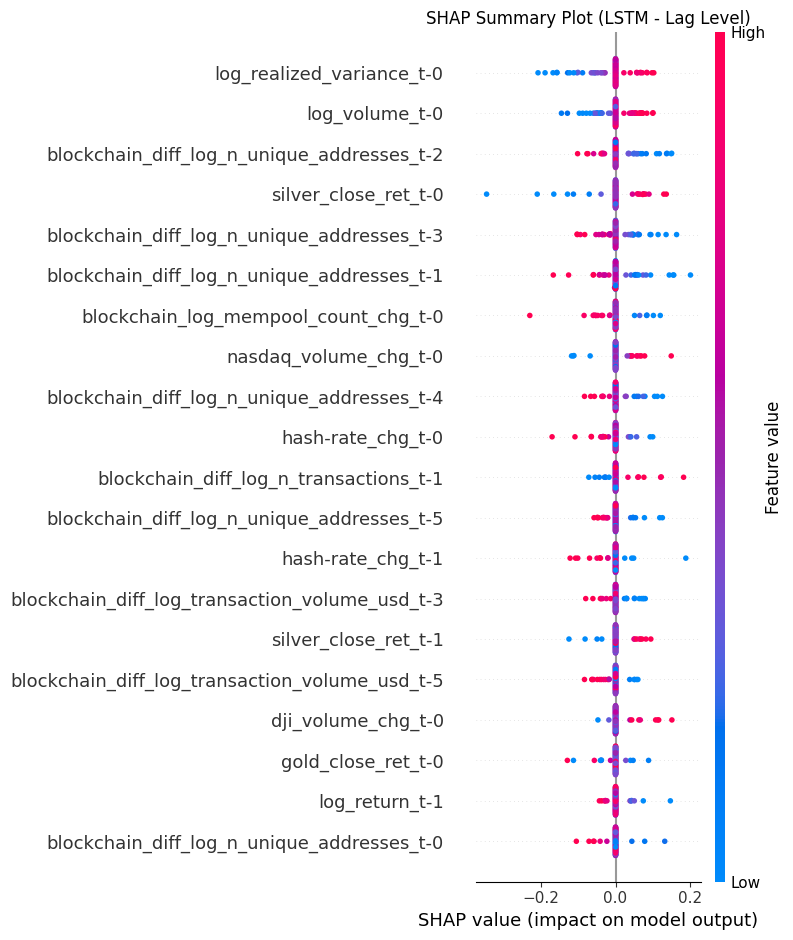

sv_feature shape: (100, 29)
X_feature shape: (100, 29)


/var/folders/2h/gvrjdw1x6t766jgk66w62_tw0000gn/T/ipykernel_7229/799558395.py:139: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


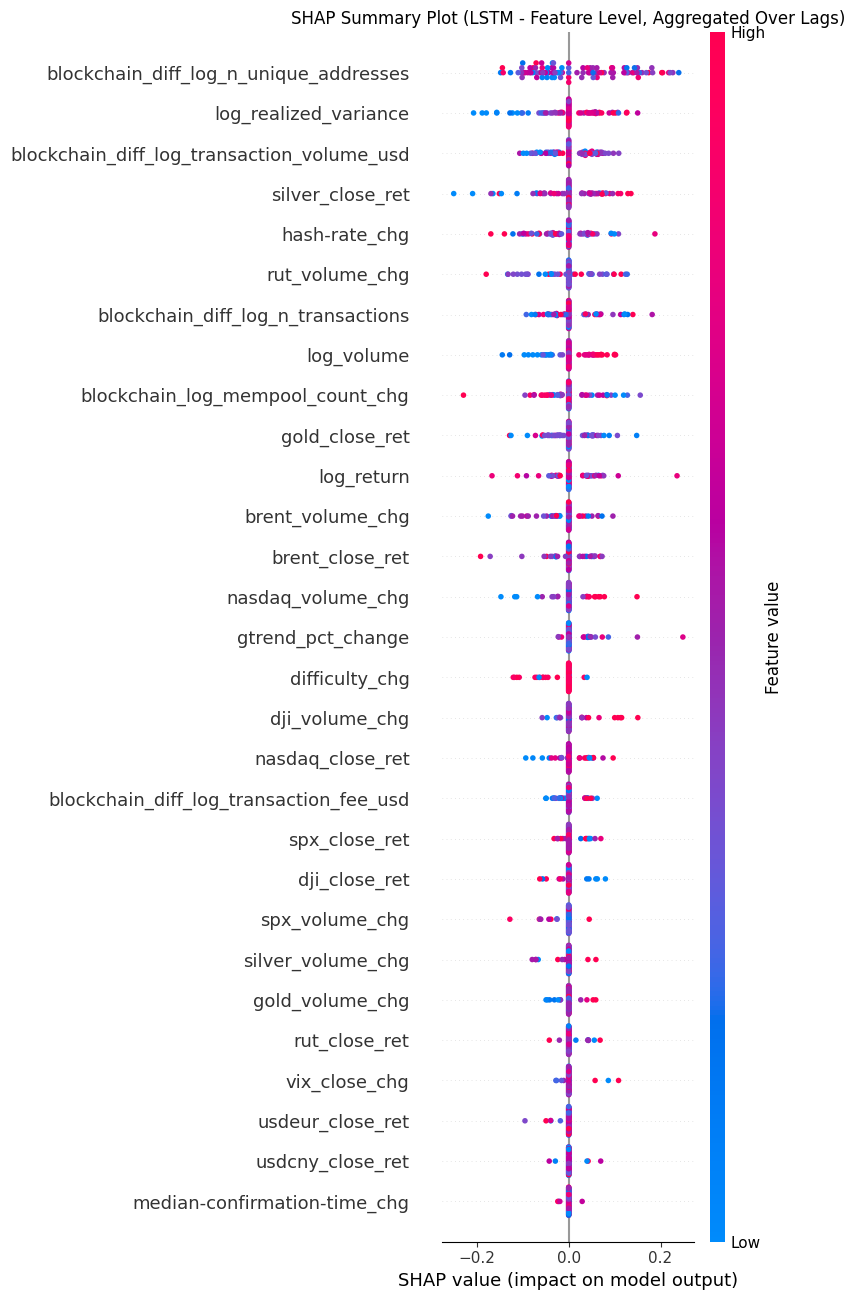


LSTM Feature Importance (aggregated over lags):
                                       feature  mean_abs_shap
5       blockchain_diff_log_n_unique_addresses       0.093986
9                             silver_close_ret       0.040695
0                        log_realized_variance       0.039967
6   blockchain_diff_log_transaction_volume_usd       0.037482
25                               hash-rate_chg       0.032680
22                              rut_volume_chg       0.027061
3           blockchain_diff_log_n_transactions       0.025163
7                                   log_volume       0.024795
28            blockchain_log_mempool_count_chg       0.024350
8                               gold_close_ret       0.022205
1                                   log_return       0.020553
19                            brent_volume_chg       0.018988
10                             brent_close_ret       0.014868
23                           nasdaq_volume_chg       0.012930
2                    

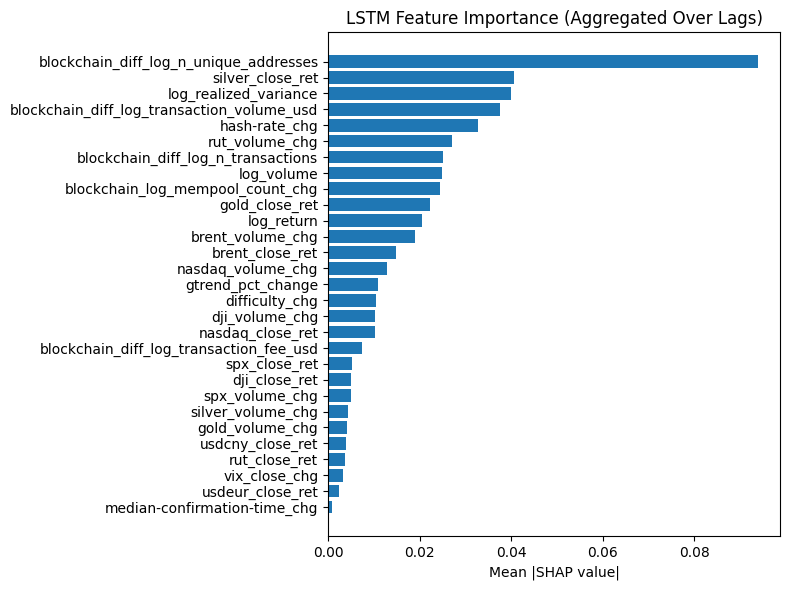


Top 15 LSTM Lag Importance:
     lag  mean_abs_shap
59   t-0       0.170664
58   t-1       0.081216
57   t-2       0.053995
56   t-3       0.051911
55   t-4       0.040962
54   t-5       0.034096
53   t-6       0.026591
52   t-7       0.014872
51   t-8       0.012245
50   t-9       0.007869
41  t-18       0.002613
40  t-19       0.002527
48  t-11       0.002467
49  t-10       0.002399
45  t-14       0.002296


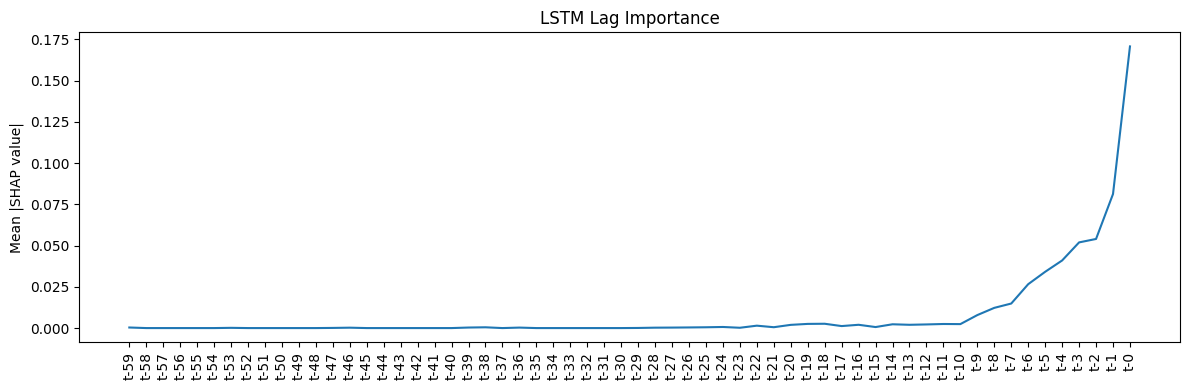


Feature x Lag importance matrix shape: (60, 29)


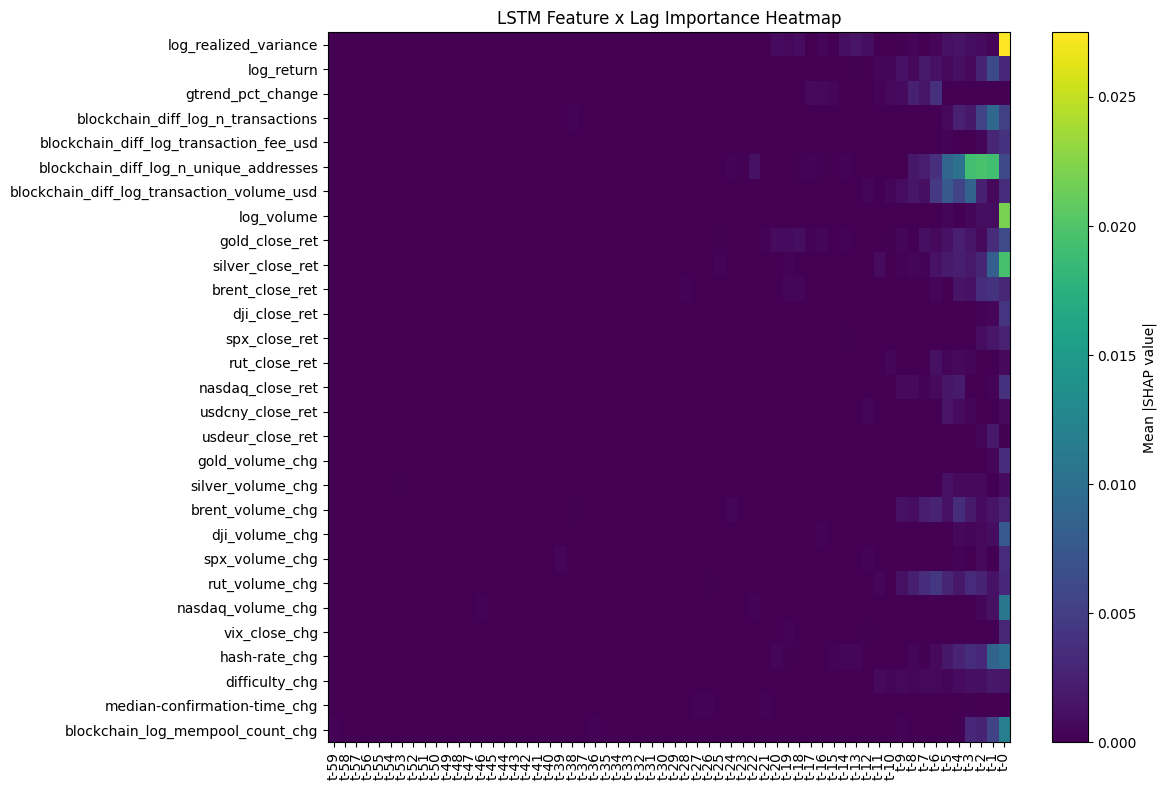

In [ ]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt


# inputs: 
# - final_lstm_model
# - X_test_lstm              shape: (n_test, n_timesteps, n_features)
# - lstm_features            
# =====================================================

# -----------------------------
# 0. Basic dimensions
# -----------------------------
n_test, n_timesteps, n_features = X_test_lstm.shape
print("X_test_lstm shape:", X_test_lstm.shape)

# -----------------------------
# 1. Flatten LSTM input
# -----------------------------
X_test_flat = X_test_lstm.reshape(n_test, n_timesteps * n_features)
print("X_test_flat shape:", X_test_flat.shape)

# lagged feature names for lag-level SHAP plot
lag_feature_names = []
for lag in range(n_timesteps):
    for feat in lstm_features:
        lag_feature_names.append(f"{feat}_t-{n_timesteps - 1 - lag}")

# -----------------------------
# 2. Wrapper for KernelExplainer
# -----------------------------
def model_wrapper(X_input):
    X_input = np.array(X_input)
    X_seq = X_input.reshape(-1, n_timesteps, n_features)
    preds = final_lstm_model.predict(X_seq, verbose=0)
    return preds   # shape: (n_samples, n_classes)

# -----------------------------
# 3. Select background and explain set
# Kernel SHAP is slow, so keep this small
# -----------------------------
np.random.seed(42)

background_size = min(30, n_test)
explain_size = min(100, n_test)

background_idx = np.random.choice(n_test, background_size, replace=False)
remaining_idx = np.setdiff1d(np.arange(n_test), background_idx)

if len(remaining_idx) >= explain_size:
    explain_idx = np.random.choice(remaining_idx, explain_size, replace=False)
else:
    explain_idx = np.random.choice(n_test, explain_size, replace=False)

background = X_test_flat[background_idx]
X_explain = X_test_flat[explain_idx]

print("background shape:", background.shape)
print("X_explain shape:", X_explain.shape)

# -----------------------------
# 4. Compute SHAP
# -----------------------------
explainer = shap.KernelExplainer(model_wrapper, background)
shap_values = explainer.shap_values(X_explain)

print("SHAP computed.")

# -----------------------------
# 5. Pick class to explain (high regime in this case)
# -----------------------------
if isinstance(shap_values, list):
    print("shap_values is a list with length:", len(shap_values))
    sv = shap_values[1]
else:
    sv = shap_values

# Some SHAP versions may return 3D output: (samples, flat_features, classes)
if sv.ndim == 3:
    print("3D SHAP output detected:", sv.shape)
    sv = sv[:, :, 1]

print("Selected SHAP array shape:", sv.shape)

# -----------------------------
# 6. Reshape SHAP back to 3D
# shape: (n_explain, n_timesteps, n_features)
# -----------------------------
n_explain = sv.shape[0]
sv_3d = sv.reshape(n_explain, n_timesteps, n_features)

# reshape explained inputs too
X_explain_3d = X_explain.reshape(n_explain, n_timesteps, n_features)

print("sv_3d shape:", sv_3d.shape)
print("X_explain_3d shape:", X_explain_3d.shape)


# PART A: LAG-LEVEL SHAP (shows feature x lag importance)
# flatten SHAP back to 2D for lag-level plot
sv_lag = sv_3d.reshape(n_explain, n_timesteps * n_features)
X_lag = X_explain_3d.reshape(n_explain, n_timesteps * n_features)

print("sv_lag shape:", sv_lag.shape)
print("X_lag shape:", X_lag.shape)

plt.figure(figsize=(12, 8))
shap.summary_plot(
    sv_lag,
    X_lag,
    feature_names=lag_feature_names,
    max_display=20,
    show=False
)
plt.title("SHAP Summary Plot (LSTM - Lag Level)")
plt.tight_layout()
plt.show()


# PART B: FEATURE-LEVEL SHAP (aggregated over lags)
# one row per original feature


# signed (sum) aggregation over lags
sv_feature = sv_3d.sum(axis=1)     # shape: (n_explain, n_features)

# use last timestep feature values for coloring
X_feature = X_explain_3d[:, -1, :] # shape: (n_explain, n_features)

print("sv_feature shape:", sv_feature.shape)
print("X_feature shape:", X_feature.shape)

plt.figure(figsize=(10, 6))
shap.summary_plot(
    sv_feature,
    X_feature,
    feature_names=lstm_features,
    max_display=len(lstm_features),
    show=False
)
plt.title("SHAP Summary Plot (LSTM - Feature Level, Aggregated Over Lags)")
plt.tight_layout()
plt.show()


# PART C: mean absolute SHAP aggregated over lags
feature_importance = np.abs(sv_3d).sum(axis=1).mean(axis=0)

feature_importance_df = pd.DataFrame({
    "feature": lstm_features,
    "mean_abs_shap": feature_importance
}).sort_values("mean_abs_shap", ascending=False)

print("\nLSTM Feature Importance (aggregated over lags):")
print(feature_importance_df)

plt.figure(figsize=(8, 6))
plt.barh(
    feature_importance_df["feature"][::-1],
    feature_importance_df["mean_abs_shap"][::-1]
)
plt.xlabel("Mean |SHAP value|")
plt.title("LSTM Feature Importance (Aggregated Over Lags)")
plt.tight_layout()
plt.show()


# PART D: LAG IMPORTANCE TABLE + BAR CHART
lag_importance = np.abs(sv_3d).mean(axis=0).sum(axis=1)

lag_labels = [f"t-{n_timesteps - 1 - lag}" for lag in range(n_timesteps)]

lag_importance_df = pd.DataFrame({
    "lag": lag_labels,
    "mean_abs_shap": lag_importance
}).sort_values("mean_abs_shap", ascending=False)

print("\nTop 15 LSTM Lag Importance:")
print(lag_importance_df.head(15))

# plot in original time order
lag_importance_plot_df = pd.DataFrame({
    "lag": [f"t-{n_timesteps - 1 - lag}" for lag in range(n_timesteps)],
    "mean_abs_shap": np.abs(sv_3d).mean(axis=0).sum(axis=1)
})

plt.figure(figsize=(12, 4))
plt.plot(lag_importance_plot_df["lag"], lag_importance_plot_df["mean_abs_shap"])
plt.xticks(rotation=90)
plt.ylabel("Mean |SHAP value|")
plt.title("LSTM Lag Importance")
plt.tight_layout()
plt.show()


# PART E: FEATURE x LAG HEATMAP
# determine feature matters at which lag


feature_lag_importance = np.abs(sv_3d).mean(axis=0)   # shape: (timesteps, features)

feature_lag_df = pd.DataFrame(
    feature_lag_importance,
    columns=lstm_features,
    index=[f"t-{n_timesteps - 1 - lag}" for lag in range(n_timesteps)]
)

print("\nFeature x Lag importance matrix shape:", feature_lag_df.shape)

plt.figure(figsize=(12, 8))
plt.imshow(feature_lag_df.T, aspect='auto')
plt.yticks(range(len(lstm_features)), lstm_features)
plt.xticks(range(n_timesteps), feature_lag_df.index, rotation=90)
plt.colorbar(label="Mean |SHAP value|")
plt.title("LSTM Feature x Lag Importance Heatmap")
plt.tight_layout()
plt.show()


In [ ]:
# save outputs to CSV (uncomment below)

#feature_importance_df.to_csv("model_final/lstm_feature_importance_shap2.csv", index=False)
#lag_importance_df.to_csv("model_final/lstm_lag_importance_shap2.csv", index=False)
#feature_lag_df.to_csv("model_final/lstm_feature_lag_importance_shap2.csv")



Saved files:
- lstm_feature_importance_shap2.csv
- lstm_lag_importance_shap2.csv
- lstm_feature_lag_importance_shap2.csv
